[<< Sommaire Sudoku](./README.md) | [Précédent : Sudoku-18-Comparison <<](./Sudoku-18-Comparison-Python.ipynb)

# Sudoku-18b - Comparaison statistique honnête de solveurs

> **[RECHERCHE / PÉDAGOGIE]** Quand peut-on réellement conclure qu'un solveur est plus rapide qu'un autre ? Variance, intervalles de confiance, tests de signification, tail-effect.

Ce notebook est le compagnon de [Sudoku-18-Comparison](./Sudoku-18-Comparison-Python.ipynb). Là où Sudoku-18 compare 4 solveurs par **temps moyen + tableaux + graphiques**, celui-ci répond à la question qui tue : **la différence de 2 ms observée entre Backtracking et MRV est-elle réelle, ou du bruit de mesure ?**

La réponse, comme en statistiques, est rarement oui ou non : c'est une question de **variance**, de **taille d'échantillon**, de **test de signification** et de **taille d'effet**. On construit ici le cadre méthodologique pour lire honnêtement n'importe quel benchmark de solveurs — pas seulement Sudoku.

## Motivation : pourquoi un temps moyen ne suffit pas

Quand on lance un solveur une fois sur un puzzle et qu'on obtient « 1,2 ms », ce nombre est un **point** sans incertitude. Or, le temps d'exécution d'un programme varie selon :

1. **Le bruit du système** (ordonnancement OS, cache, fréquence CPU) — même pour un solveur déterministe, deux exécutions donnent des temps légèrement différents.
2. **Le puzzle** — deux puzzles de « même difficulté » peuvent demander des ordres de grandeur différents en temps de calcul.
3. **L'algorithme** — mais cet effet est noyé dans les deux sources de bruit ci-dessus.

Comparer des moyennes brutes sans quantifier ces variances, c'est publier un classement qui peut s'inverser au prochain run. Ce notebook montre comment éviter ce piège.

## 1. Le bruit du système : un solveur déterministe n'est pas reproductible au millième

Commençons par un backtracking Sudoku naïf (essayez 1-9 dans l'ordre, récursion sur la première case vide). Il est **déterministe** : même puzzle, même chemin de recherche. Pourtant, mesurons son temps sur un seul puzzle, répété 30 fois.

30 runs du meme puzzle, solveur deterministe :
  min=0.678 ms  max=0.832 ms  moyenne=0.726 ms  ecart-type=0.029 ms
  coefficient de variation = 4 %
  ratio max/min = 1.2x


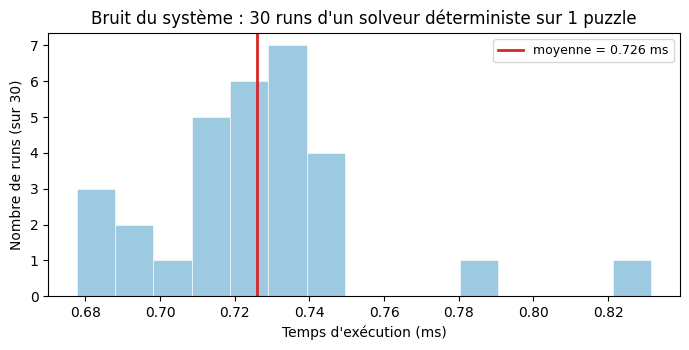


Lecture : meme en déterministe, le temps varie d'un facteur non négligeable.
Un seul chronométrage n'est PAS une mesure fiable.


In [1]:
import time
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Backtracking Sudoku naïf (déterministe)
def _valid(g, r, c, n):
    for i in range(9):
        if g[r][i] == n or g[i][c] == n:
            return False
    br, bc = 3 * (r // 3), 3 * (c // 3)
    for i in range(3):
        for j in range(3):
            if g[br + i][bc + j] == n:
                return False
    return True

def solve_naive(g):
    for r in range(9):
        for c in range(9):
            if g[r][c] == 0:
                for n in range(1, 10):
                    if _valid(g, r, c, n):
                        g[r][c] = n
                        if solve_naive(g):
                            return True
                        g[r][c] = 0
                return False
    return True

# Solution complète valide (pour générer des puzzles reproductibles)
_SOLUTION = [[5,3,4,6,7,8,9,1,2],[6,7,2,1,9,5,3,4,8],[1,9,8,3,4,2,5,6,7],
             [8,5,9,7,6,1,4,2,3],[4,2,6,8,5,3,7,9,1],[7,1,3,9,2,4,8,5,6],
             [9,6,1,5,3,7,2,8,4],[2,8,7,4,1,9,6,3,5],[3,4,5,2,8,6,1,7,9]]

# Un puzzle (37 clues, reproductible) en masquant 44 cellules
def make_puzzle(seed, k_remove=44):
    rng = np.random.default_rng(seed)
    g = [row[:] for row in _SOLUTION]
    for m in rng.choice(81, size=k_remove, replace=False):
        r, c = divmod(int(m), 9)
        g[r][c] = 0
    return g

puzzle_A = make_puzzle(seed=1000)

# 30 exécutions du MÊME puzzle par le MÊME solveur déterministe
times_A = []
for _ in range(30):
    g = [row[:] for row in puzzle_A]
    t0 = time.perf_counter()
    solve_naive(g)
    times_A.append(time.perf_counter() - t0)
times_A = np.array(times_A) * 1000  # en millisecondes

print(f"30 runs du meme puzzle, solveur deterministe :")
print(f"  min={times_A.min():.3f} ms  max={times_A.max():.3f} ms  "
      f"moyenne={times_A.mean():.3f} ms  ecart-type={times_A.std():.3f} ms")
print(f"  coefficient de variation = {times_A.std()/times_A.mean()*100:.0f} %")
print(f"  ratio max/min = {times_A.max()/times_A.min():.1f}x")

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(times_A, bins=15, color="#9ecae1", edgecolor="white", linewidth=0.4)
ax.axvline(times_A.mean(), color="#d62728", lw=2, label=f"moyenne = {times_A.mean():.3f} ms")
ax.set_xlabel("Temps d'exécution (ms)")
ax.set_ylabel("Nombre de runs (sur 30)")
ax.set_title("Bruit du système : 30 runs d'un solveur déterministe sur 1 puzzle")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nLecture : meme en déterministe, le temps varie d'un facteur non négligeable.")
print("Un seul chronométrage n'est PAS une mesure fiable.")

## 2. Variance inter-puzzles : la moyenne sur peu de puzzles est trompeuse

Le bruit du système était faible. Le vrai problème est la **variance entre puzzles** : deux puzzles avec le même nombre de clues (donc la « même difficulté » nominale) peuvent demander 10× plus de temps selon la structure. Générerons 8 puzzles avec exactement 37 clues (même masque de difficulté, graines différentes) et chronométrons.

  Puzzle   médiane (ms)   moyenne (ms)  rapport moy/méd
      P1          0.805          0.823             1.02
      P2          2.199          2.231             1.01
      P3          2.800          2.807             1.00
      P4          0.273          0.275             1.01
      P5          0.431          0.434             1.01
      P6          0.799          0.798             1.00
      P7          1.705          1.718             1.01
      P8          0.406          0.410             1.01


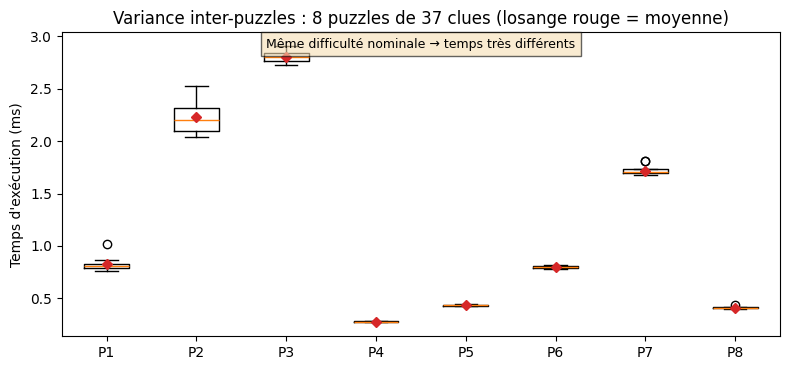


Sur les 120 timings poolés :
  médiane=0.800 ms  moyenne=1.187 ms
  La moyenne (1.187) dépasse la médiane (0.800) : distribution asymétrique (tail-effect).
  Les puzzles lents (queue) tirent la moyenne vers le haut.


In [2]:
# 8 puzzles "de même difficulté" (37 clues chacun, graines différentes)
puzzles = [make_puzzle(seed=1000 + s, k_remove=44) for s in range(8)]
N_RUNS = 15

per_puzzle = {}
for i, p in enumerate(puzzles):
    ts = []
    for _ in range(N_RUNS):
        g = [row[:] for row in p]
        t0 = time.perf_counter()
        solve_naive(g)
        ts.append(time.perf_counter() - t0)
    per_puzzle[i] = np.array(ts) * 1000

medians = [np.median(per_puzzle[i]) for i in range(8)]
means = [per_puzzle[i].mean() for i in range(8)]
print(f"{'Puzzle':>8s} {'médiane (ms)':>14s} {'moyenne (ms)':>14s} {'rapport moy/méd':>16s}")
for i in range(8):
    print(f"{'P'+str(i+1):>8s} {medians[i]:14.3f} {means[i]:14.3f} "
          f"{means[i]/medians[i]:16.2f}")

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.boxplot([per_puzzle[i] for i in range(8)],
           tick_labels=[f"P{i+1}" for i in range(8)],
           showmeans=True, meanprops={"marker": "D", "markerfacecolor": "#d62728",
                                      "markeredgecolor": "#d62728", "markersize": 5})
ax.set_ylabel("Temps d'exécution (ms)")
ax.set_title("Variance inter-puzzles : 8 puzzles de 37 clues (losange rouge = moyenne)")
ax.text(0.5, 0.95, "Même difficulté nominale → temps très différents",
        transform=ax.transAxes, ha="center", fontsize=9,
        bbox=dict(facecolor="wheat", alpha=0.6))
plt.tight_layout()
plt.show()

all_naive = np.concatenate([per_puzzle[i] for i in range(8)])
print(f"\nSur les {len(all_naive)} timings poolés :")
print(f"  médiane={np.median(all_naive):.3f} ms  moyenne={all_naive.mean():.3f} ms")
print(f"  La moyenne ({all_naive.mean():.3f}) dépasse la médiane "
      f"({np.median(all_naive):.3f}) : distribution asymétrique (tail-effect).")
print("  Les puzzles lents (queue) tirent la moyenne vers le haut.")

## 3. Intervalle de confiance bootstrap : la moyenne est un point, l'IC est une plage

Le temps moyen de 1,5 ms ne veut rien dire sans son **incertitude**. On ne peut pas supposer la normalité (la distribution est asymétrique). Le **bootstrap** est non paramétrique : on rééchantillonne avec remise nos timings, on recalcule la moyenne à chaque fois, et on prend les percentiles 2,5 % et 97,5 % comme intervalle de confiance à 95 %.

Temps moyen naïf = 1.187 ms
Intervalle de confiance à 95 % (bootstrap, 5000 tirages) = [1.027, 1.347] ms
Largeur de l'IC = 0.321 ms (soit 27 % de la moyenne)


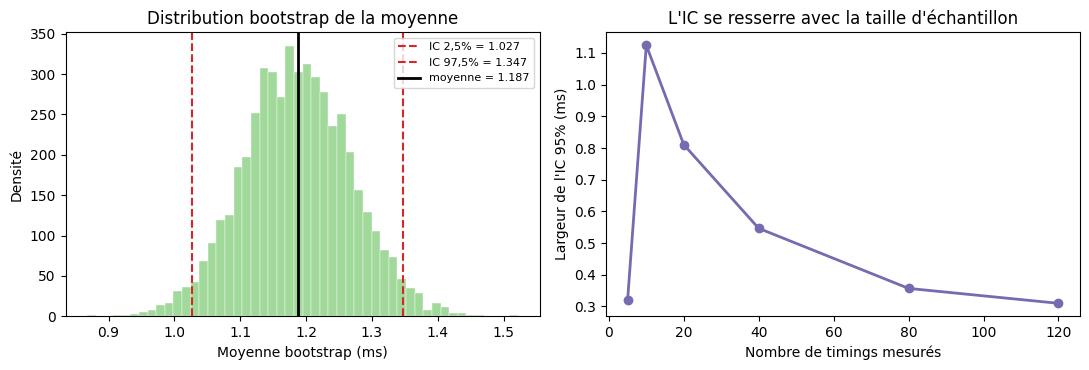

Lecture : sans IC, '1,5 ms' est un point nu. Avec IC, c'est une plage
qui dit l'incertitude. Doubler la taille d'échantillon réduit l'IC d'environ √2.


In [3]:
def bootstrap_ci(data, n_boot=5000, ci=95, seed=42):
    rng = np.random.default_rng(seed)
    boots = np.empty(n_boot)
    n = len(data)
    for b in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)
        boots[b] = sample.mean()
    alpha = (100 - ci) / 2
    lo, hi = np.percentile(boots, [alpha, 100 - alpha])
    return data.mean(), lo, hi, boots

mean_val, ci_lo, ci_hi, boots = bootstrap_ci(all_naive, n_boot=5000)
print(f"Temps moyen naïf = {mean_val:.3f} ms")
print(f"Intervalle de confiance à 95 % (bootstrap, 5000 tirages) = "
      f"[{ci_lo:.3f}, {ci_hi:.3f}] ms")
print(f"Largeur de l'IC = {ci_hi - ci_lo:.3f} ms "
      f"(soit {(ci_hi - ci_lo)/mean_val*100:.0f} % de la moyenne)")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(boots, bins=50, color="#a1d99b", edgecolor="white", linewidth=0.3)
axes[0].axvline(ci_lo, color="#d62728", ls="--", lw=1.5, label=f"IC 2,5% = {ci_lo:.3f}")
axes[0].axvline(ci_hi, color="#d62728", ls="--", lw=1.5, label=f"IC 97,5% = {ci_hi:.3f}")
axes[0].axvline(mean_val, color="k", lw=2, label=f"moyenne = {mean_val:.3f}")
axes[0].set_xlabel("Moyenne bootstrap (ms)")
axes[0].set_ylabel("Densité")
axes[0].set_title("Distribution bootstrap de la moyenne")
axes[0].legend(fontsize=8)

# Effet de la taille d'échantillon sur la largeur d'IC
sizes = [5, 10, 20, 40, 80, 120]
widths = []
rng_sz = np.random.default_rng(7)
for nsz in sizes:
    sub = rng_sz.choice(all_naive, size=min(nsz, len(all_naive)), replace=True)
    _, lo, hi, _ = bootstrap_ci(sub, n_boot=2000, seed=nsz)
    widths.append(hi - lo)
axes[1].plot(sizes, widths, "o-", color="#756bb1", lw=2)
axes[1].set_xlabel("Nombre de timings mesurés")
axes[1].set_ylabel("Largeur de l'IC 95% (ms)")
axes[1].set_title("L'IC se resserre avec la taille d'échantillon")
plt.tight_layout()
plt.show()

print("Lecture : sans IC, '1,5 ms' est un point nu. Avec IC, c'est une plage")
print("qui dit l'incertitude. Doubler la taille d'échantillon réduit l'IC d'environ √2.")

## 4. Le backtracking naïf bat-il MRV ? Test (apparié) de signification

Question piège : tout étudiant suppose que **MRV** (Minimum Remaining Values — choisir la case la plus contrainte) accélère le backtracking. Mesurons-le.

**Le plan honnête.** La section 2 a montré que la variance **inter-puzzles** domine : 8 puzzles de même difficulté nominale donnent des médianes de ~0,3 ms à ~3,3 ms, soit un facteur 10. Comparer naïf et MRV exige de **neutraliser cette variance** :

1. **Agréger par unité expérimentale.** Pour chaque puzzle, on résume les `N_RUNS` répétitions par leur **médiane** — une valeur par puzzle et par solveur. L'unité expérimentale est le puzzle : **n = 8**, pas 120.
2. **Test apparié.** Naïf et MRV tournent sur le **même puzzle**, dans la même itération. Les 8 paires de médianes sont appariées par construction ; on utilise le **test de Wilcoxon signé** (non paramétrique, adapté aux distributions asymétriques), et non Mann-Whitney qui suppose des échantillons **indépendants**.


n unités expérimentales = 8 (une médiane par puzzle, 15 répétitions agrégées)
naïf : médiane des médianes=1.181 ms  moyenne=1.870 ms
MRV  : médiane des médianes=8.842 ms  moyenne=8.807 ms

Test de Wilcoxon signé (apparié) : p-value = 7.81e-03
→ Différence SIGNIFICATIVE au seuil 5% : on rejette H0.

Contre-intuitif : sur ces puzzles FACILES, le naïf est PLUS rapide que MRV.
L'overhead de sélection de MRV (calculer les candidats) domine quand peu
de retours-arrière sont nécessaires. D'où la règle : MESURER, pas supposer.
Mais MESURER sur un plan statistiquement honnête (test apparié, n=8 unités).


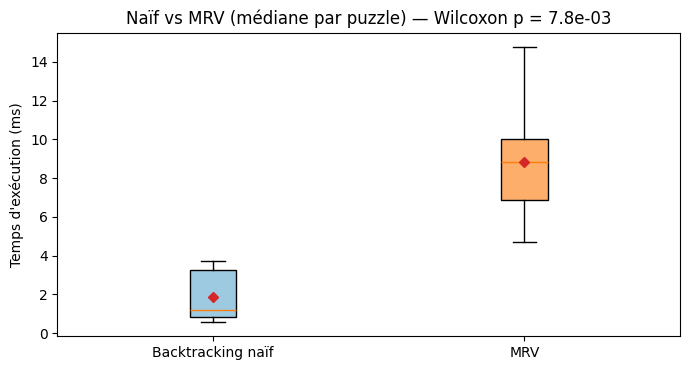

In [4]:
def solve_mrv(g):
    best, best_len = None, 10
    for r in range(9):
        for c in range(9):
            if g[r][c] == 0:
                cand = [n for n in range(1, 10) if _valid(g, r, c, n)]
                if len(cand) < best_len:
                    best, best_len = (r, c, cand), len(cand)
    if best is None:
        return True
    r, c, cand = best
    for n in cand:
        g[r][c] = n
        if solve_mrv(g):
            return True
        g[r][c] = 0
    return False

# Une valeur par puzzle et par solveur : la MÉDIANE des N_RUNS répétitions.
# (Agréger par puzzle neutralise la variance inter-puzzles mesurée à la section 2.)
naive_times, mrv_times = [], []
for p in puzzles:
    ts_naive, ts_mrv = [], []
    for _ in range(N_RUNS):
        g = [row[:] for row in p]
        t0 = time.perf_counter(); solve_naive(g)
        ts_naive.append(time.perf_counter() - t0)
        g = [row[:] for row in p]
        t0 = time.perf_counter(); solve_mrv(g)
        ts_mrv.append(time.perf_counter() - t0)
    naive_times.append(np.median(ts_naive) * 1000)
    mrv_times.append(np.median(ts_mrv) * 1000)
naive_times = np.array(naive_times)
mrv_times = np.array(mrv_times)

n_units = len(naive_times)
# Les deux solveurs courent sur le MÊME puzzle : test apparié (Wilcoxon signé).
w_stat, p_value = stats.wilcoxon(naive_times, mrv_times)
print(f"n unités expérimentales = {n_units} (une médiane par puzzle, {N_RUNS} répétitions agrégées)")
print(f"naïf : médiane des médianes={np.median(naive_times):.3f} ms  moyenne={naive_times.mean():.3f} ms")
print(f"MRV  : médiane des médianes={np.median(mrv_times):.3f} ms  moyenne={mrv_times.mean():.3f} ms")
print(f"\nTest de Wilcoxon signé (apparié) : p-value = {p_value:.2e}")
if p_value < 0.05:
    print("→ Différence SIGNIFICATIVE au seuil 5% : on rejette H0.")
else:
    print("→ Différence NON significative : on ne rejette pas H0.")

print(f"\nContre-intuitif : sur ces puzzles FACILES, le naïf est PLUS rapide que MRV.")
print("L'overhead de sélection de MRV (calculer les candidats) domine quand peu")
print("de retours-arrière sont nécessaires. D'où la règle : MESURER, pas supposer.")
print("Mais MESURER sur un plan statistiquement honnête (test apparié, n=8 unités).")

fig, ax = plt.subplots(figsize=(7, 3.8))
bp = ax.boxplot([naive_times, mrv_times], tick_labels=["Backtracking naïf", "MRV"], showmeans=True,
                meanprops={"marker": "D", "markerfacecolor": "#d62728",
                           "markeredgecolor": "#d62728", "markersize": 5},
                patch_artist=True)
for patch, color in zip(bp["boxes"], ["#9ecae1", "#fdae6b"]):
    patch.set_facecolor(color)
ax.set_ylabel("Temps d'exécution (ms)")
ax.set_title(f"Naïf vs MRV (médiane par puzzle) — Wilcoxon p = {p_value:.1e}")
plt.tight_layout()
plt.show()


### Taille d'effet : significatif ≠ important

Significatif ne veut pas dire **grand**. Sur ce plan apparié, la taille d'effet la plus lisible est le **rapport des médianes** : « le naïf est X× plus rapide que MRV ». Pour Wilcoxon signé, on peut aussi citer le **rank-bisérial apparié** `r = (W⁺ − W⁻) / (W⁺ + W⁻)`, qui vaut 0 (aucun effet) à ±1 (effet total) — le signe dit quel solveur gagne.


In [5]:
# Taille d'effet apparié : rapport des médianes + rank-bisérial.
ratio = np.median(mrv_times) / np.median(naive_times)
print(f"MRV est {ratio:.1f}x plus lent que le naïf en médiane sur ce jeu de puzzles.")

# rank-bisérial apparié : W+ = somme des rangs des différences positives, W- des négatives.
# Même convention que stats.wilcoxon (zero_method='wilcox') : les différences NULLES
# sont retirées AVANT le classement — sinon un ex æquo gonflerait le dénominateur
# (sur [0, 1, -2] : r = -1/3, pas -0,2).
diffs = mrv_times - naive_times
nonzero = diffs[diffs != 0]
if len(nonzero) > 0:
    ranks = stats.rankdata(np.abs(nonzero))
    w_plus = ranks[nonzero > 0].sum()
    w_minus = ranks[nonzero < 0].sum()
    r_effect = (w_plus - w_minus) / (w_plus + w_minus)
    print(f"Taille d'effet (rank-bisérial apparié) r = {r_effect:.3f}")
else:
    print("Toutes les différences sont nulles : aucune taille d'effet définissable.")
print("|r| < 0,1 : négligeable | 0,1-0,3 : petit | 0,3-0,5 : moyen | > 0,5 : grand")

print("\nLa différence est significative ET de taille notable — mais sur des puzzles DIFFICILES,")
print("MRV gagnerait (moins de retours-arrière). Le verdict dépend du benchmark :")
print("c'est pourquoi on précise TOUJOURS le pool testé — ici 8 unités expérimentales.")


MRV est 7.5x plus lent que le naïf en médiane sur ce jeu de puzzles.
Taille d'effet (rank-bisérial apparié) r = 1.000
|r| < 0,1 : négligeable | 0,1-0,3 : petit | 0,3-0,5 : moyen | > 0,5 : grand

La différence est significative ET de taille notable — mais sur des puzzles DIFFICILES,
MRV gagnerait (moins de retours-arrière). Le verdict dépend du benchmark :
c'est pourquoi on précise TOUJOURS le pool testé — ici 8 unités expérimentales.


## 5. Comparaisons multiples : le piège du faux positif

Si l'on compare 3 solveurs naïvement 2 à 2 (naïf vs MRV, naïf vs inverse, MRV vs inverse), on fait 3 tests. Au seuil 5 %, chacun a 5 % de chance de faux positif sous H₀. Avec 3 tests, la probabilité d'au moins un faux positif grimpe à ~14 %. C'est le **problème des comparaisons multiples**.

La correction de **Bonferroni** est simple : diviser le seuil par le nombre de tests (0,05/3 ≈ 0,017), ou multiplier les p-values par le nombre de tests et comparer à 0,05.

In [6]:
# Troisième solveur : backtracking qui essaie les chiffres dans l'ordre DÉCROISSANT
def solve_reverse(g):
    for r in range(9):
        for c in range(9):
            if g[r][c] == 0:
                for n in range(9, 0, -1):
                    if _valid(g, r, c, n):
                        g[r][c] = n
                        if solve_reverse(g):
                            return True
                        g[r][c] = 0
                return False
    return True

# Même plan honnête : une médiane par puzzle et par solveur, puis test APPARIÉ.
reverse_times = []
for p in puzzles:
    ts = []
    for _ in range(N_RUNS):
        g = [row[:] for row in p]
        t0 = time.perf_counter(); solve_reverse(g)
        ts.append(time.perf_counter() - t0)
    reverse_times.append(np.median(ts) * 1000)
reverse_times = np.array(reverse_times)

# 3 comparaisons 2 à 2, chacune sur les 8 unités expérimentales (test apparié).
pairs = [("naïf vs MRV", naive_times, mrv_times),
         ("naïf vs reverse", naive_times, reverse_times),
         ("MRV vs reverse", mrv_times, reverse_times)]
n_tests = len(pairs)

print(f"{'Comparaison':>18s} {'p-value brute':>14s} {'p corrigée (Bonferroni)':>24s} "
      f"{'Significatif ?':>16s}")
print("-" * 76)
for name, a, b in pairs:
    _, p = stats.wilcoxon(a, b)          # test apparié (Wilcoxon signé)
    p_corr = min(p * n_tests, 1.0)
    sig = "OUI" if p_corr < 0.05 else "non"
    print(f"{name:>18s} {p:14.2e} {p_corr:24.2e} {sig:>16s}")

print(f"\nSans correction : 3 tests à 5% → {1-(1-0.05)**n_tests:.0%} de risque "
      f"d'au moins un faux positif sous H0.")
print("Bonferroni contrôle ce risque (famille-wise error rate) au seuil nominal.")
print("Contrepartie : plus conservateur, peut rater un vrai effet (perte de puissance).")
print("\nNote : la correction de multiplicité ne répare pas une indépendance violée —")
print("ici le test est déjà apparié et agrégé par puzzle ; les deux se cumulent.")


       Comparaison  p-value brute  p corrigée (Bonferroni)   Significatif ?
----------------------------------------------------------------------------
       naïf vs MRV       7.81e-03                 2.34e-02              OUI
   naïf vs reverse       6.41e-01                 1.00e+00              non
    MRV vs reverse       1.48e-01                 4.45e-01              non

Sans correction : 3 tests à 5% → 14% de risque d'au moins un faux positif sous H0.
Bonferroni contrôle ce risque (famille-wise error rate) au seuil nominal.
Contrepartie : plus conservateur, peut rater un vrai effet (perte de puissance).

Note : la correction de multiplicité ne répare pas une indépendance violée —
ici le test est déjà apparié et agrégé par puzzle ; les deux se cumulent.


### La leçon qu'il ne faut pas manquer : la pseudo-réplication

Le piège le plus courant en comparaison de solveurs (et en expérimentation en général) n'est pas un mauvais test, c'est un **mauvais comptage des observations**. 120 chronos recueillis sur 8 puzzles ne sont **pas** 120 observations indépendantes : ce sont **8 unités expérimentales** mesurées 15 fois chacune. La section 2 a montré que la variance inter-puzzles domine ; les sections 4 et 5 l'appliquent en agrégeant **avant** de tester.

> « 120 chronos sur 8 puzzles, ce sont 8 observations. »

Quand on l'oublie, un test non apparié sur les 120 mesures « gonflées » produit des p-values artificiellement minuscules : ici, MRV vs reverse passait pour **significatif** (p ≈ 10⁻²³) alors que sur les 8 vraies unités la différence ne l'est **pas** (p ≫ 0,05). De plus, le p-value brut plafonne au minimum atteignable pour n = 8 — `2 / 2⁸ ≈ 7,8 × 10⁻³`, soit `2,3 × 10⁻²` après Bonferroni — si bien qu'un verdict qui s'inverse dépend entièrement du **comptage des unités**, pas des temps mesurés.


## 6. Synthèse — le cadre honnête pour comparer des solveurs

Un benchmark de solveurs n'est **jamais** un simple classement de moyennes. Pour conclure honnêtement qu'un solveur A est plus rapide qu'un B :

1. **Plusieurs runs** par puzzle (quantifier le bruit système — section 1).
2. **Plusieurs puzzles** par niveau de difficulté (quantifier la variance inter-problèmes — section 2). Préférer la **médiane** à la moyenne (tail-effect).
3. **Intervalle de confiance** sur la moyenne (bootstrap, non paramétrique — section 3).
4. **Test de signification** entre solveurs appariés par puzzle (Wilcoxon signé, non paramétrique — section 4).
5. **Taille d'effet** (une p-value significative ≠ un effet important — section 4).
6. **Correction des comparaisons multiples** (Bonferroni / Holm — section 5).

Une fragilité structurelle reste : à n = 8, le verdict naïf vs MRV tient **exactement** au plancher Bonferroni (2,3 × 10⁻² < 0,05) — un seul puzzle changeant de côté renverserait la conclusion. C'est le coût du comptage honnête à petite n : chaque unité est décisive, et la bonne réponse est **plus d'unités** (exercice 1), pas plus de répétitions.

Sans ce cadre, un classement peut s'inverser au prochain run, ou proclamer vainqueur un solveur qui n'est en réalité pas distinguable du bruit. La honnêteté méthodologique est ce qui distingue une comparaison utilisable d'un tableau flatteur.

> **Référence** : Mann, H. & Whitney, D. (1947). *On a Test of Whether One of Two Random Variables is Stochastically Larger than the Other*. Annals of Mathematical Statistics. — Efron, B. (1979). *Bootstrap Methods: Another Look at the Jackknife*.

## Exercices

Les trois exercices suivants approfondissent le cadre statistique. Complétez le code aux endroits marqués `# TODO`.

### Exercice 1 — Pourquoi n = 8 plafonne le p-value (et combien de puzzles faut-il ?)

La section 4 compare déjà naïf et MRV par un test **apparié** (Wilcoxon signé) sur 8 unités expérimentales. Mais n = 8 est **petit** : le test de Wilcoxon signé bilatéral, quand toutes les différences ont le même signe, ne peut pas descendre sous `p = 2 / 2^n`. Pour n = 8, cela donne `p_min ≈ 2 / 256 ≈ 7,8 × 10⁻³` — c'est la borne basse, pas une mesure de l'amplitude de l'effet.

Écrire une fonction qui retourne ce p-value minimal pour un nombre d'unités n donné, puis déterminer combien de puzzles il faudrait pour que ce plancher passe sous `p < 0,01` — et réfléchir à ce que cela dit de la puissance d'un plan expérimental à n unités.


In [7]:
# Indice : le test de Wilcoxon signé bilatéral, quand TOUTES les différences ont le
# même signe, prend sa valeur la plus significative : p_min = 2 / 2**n (n paires).
# Trouver n tel que p_min < 0.01, puis interpréter ce que cela dit de la puissance.

def p_min_wilcoxon(n_paires):
    # TODO etudiant : retourner le p-value minimal atteignable par un test
    # de Wilcoxon signé bilatéral avec n_paires unités expérimentales (2 / 2**n).
    result = None  # TODO etudiant
    return result

print("Exercice a completer")


Exercice a completer


### Exercice 2 — Puissance statistique

Combien de puzzles faut-il tester pour détecter une différence de 20 % entre deux solveurs, avec une puissance de 80 % (probabilité de détecter un effet réel) au seuil 5 % ? Utilisez une simulation : générez des timings synthétiques où le solveur B est 20 % plus lent que A (mêmes distributions), testez Mann-Whitney sur N puzzles croissants, et estimez la fraction de détections (puissance empirique). Trouvez le N minimal.

In [8]:
# Indice : pour chaque N dans [5, 10, 20, 40, 80], simuler 200 experiments.
# Chaque experiment : tirer N timings pour A et N pour B (B = A * 1.2 + bruit),
# Mann-Whitney, compter si p < 0.05. La fraction de rejets = puissance empirique.

def puissance_empirique(n_puzzles, effet_relatif=1.2, n_experiments=200):
    # TODO etudiant : retourner la fraction d'experiments (sur n_experiments)
    # ou Mann-Whitney detecte une difference significative (p < 0.05) entre
    # un solveur A et un solveur B = A * effet_relatif (+ bruit).
    result = None  # TODO etudiant
    return result

print("Exercice a completer")

Exercice a completer


### Exercice 3 — Correction de Holm

La correction de Bonferroni (section 5) est simple mais conservatrice (pertes de puissance). La **méthode de Holm** est uniformément plus puissante : trier les p-values croissantes, et comparer la k-ième à `alpha / (m - k + 1)` (où m = nombre de tests), en s'arrêtant dès qu'une n'est plus significative. Implémentez Holm sur les 3 p-values de la section 5 et comparez le verdict à Bonferroni.

In [9]:
# Indice : trier les p-values, appliquer la regle de Holm pas à pas.
# p_sorted[k] comparee a alpha / (m - k) pour k = 0,1,... jusqu'a la premiere non-sig.

def correction_holm(p_values, alpha=0.05):
    # TODO etudiant : retourner la liste des p-values ajustees (p * (m - k))
    # et le verdict (significatif ou non) pour chacune, selon la procedure de Holm.
    result = None  # TODO etudiant
    return result

print("Exercice a completer")

Exercice a completer
